# Model Trainging – Heart Disease Dataset
*Training and evaluation of models for Cardio - Risk Prediction project*  

---

## Table of Contents

### [1. Reproducibility & Imports](#imports)
Ensures consistent experiment setup by defining a global random seed and importing key utilities for model training, evaluation, and hyperparameter tuning.

### [2. Data Preparation](#prep)
Loads the preprocessed dataset (`df_preprocessed.csv`), displays its structure, separates features and target labels, and prepares data for modeling.

### [3. Random Forest](#random-forest)
Implements multiple Random Forest configurations for binary and multiclass classification, comparing hyperparameter setups.

- [3.1 Binary RF](#31-binary-rf-fixed) 
- [3.2 Multiclass RF](#32-multiclass-rf-fixed)

### [4. AdaBoost](#adaboost)
Tests the AdaBoost ensemble algorithm on both binary and multiclass versions of the dataset.

- [4.1 Binary Fixed](#41-binary)
- [4.2 Multiclass Fixed](#42-multiclass-fixed)

### [5. XGBoost](#xgboost)
- [5.1 Binary XGBoost](#51-binary-xgboost)
- [5.2 Multiclass XGBoost](#52-multiclass-xgboost)

<a id='imports'></a>
## Reproducibility & Imports  
---
This section provides consistent and organized experiment setup.  
- **Reproducibility:** Defines a fixed random seed (`SEED = 42`) for consistent results across runs.  
- **Path setup:** Adds project-level directories (`..` and `../scripts`) to the Python path so custom modules (e.g., `training`, `models`) can be imported.  
- **Imports:** Loads essential components for model training, tuning, and evaluation:
  - `get_cv`, `randomized_search`, `fit_eval`, `print_eval_report` – utilities for cross-validation, hyperparameter search, and performance reporting.
  - `make_rf_fixed`, `make_rf_base`, `rf_search_space`, `make_xgb_pipeline`, `xgb_search_space`, `make_ada_pipeline`, `ada_search_space` – functions for building pipelines and defining search spaces for Random Forest, XGBoost, and AdaBoost.
  - `train_test_split` from `sklearn.model_selection` – used for dataset splitting.
  - `xgboost` library and `clone` utility – for model replication and consistency checks.



In [1]:
# Reproducibility
import os, sys
import pandas as pd
import joblib

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Models & tools
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scripts.eda import plot_class_distribution
from joblib import load
from imblearn.pipeline import Pipeline

SEED = 42

In [2]:
df = pd.read_csv('../data/df_preprocessed.csv')
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,dataset_Cleveland,...,cp_non-anginal,cp_typical angina,restecg_Missing,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_Missing,slope_downsloping,slope_flat,slope_upsloping
0,1.007386,1,0.755639,-0.215021,1,0.474017,0,1.0000,0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.432034,1,1.621952,0.790195,0,-1.153349,1,0.5000,2,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.432034,1,-0.688217,-0.290886,0,-0.339666,1,1.1875,1,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.752828,1,-0.110675,0.107407,0,1.907648,0,1.7500,0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-1.328180,0,-0.110675,-0.765044,0,1.326446,0,0.4375,0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


Targets setup (for binary and mutliclass)

In [ ]:
df_copy = df.copy()
TARGET_COL = 'num'

X_full = df_copy.drop(columns=[TARGET_COL])
y_mc = df_copy[TARGET_COL].astype(int)     # multiclass
y_bin = (y_mc > 0).astype(int)             # binary

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Data split

In [5]:
# split on multiclass
X_tr, X_te, y_tr_mc, y_te_mc = train_test_split(
    X_full, y_mc,
    test_size=0.2,
    random_state=SEED,
    stratify=y_mc
)

print("Split shapes:")
print("  X_tr:", X_tr.shape, "| X_te:", X_te.shape)
print("  y_tr_mc:", y_tr_mc.shape, "| y_te_mc:", y_te_mc.shape)

# binary labels
y_tr_bin = (y_tr_mc > 0).astype(int)
y_te_bin = (y_te_mc > 0).astype(int)
print("  y_tr_bin:", y_tr_bin.shape, "| y_te_bin:", y_te_bin.shape)

Split shapes:
  X_tr: (736, 24) | X_te: (184, 24)
  y_tr_mc: (736,) | y_te_mc: (184,)
  y_tr_bin: (736,) | y_te_bin: (184,)


### Data balancing


Distribution summary for 'num':
|   Class |   Instances |   Percentage |
|--------:|------------:|-------------:|
|       0 |         411 |        20.00 |
|       1 |         411 |        20.00 |
|       2 |         411 |        20.00 |
|       3 |         411 |        20.00 |
|       4 |         411 |        20.00 |


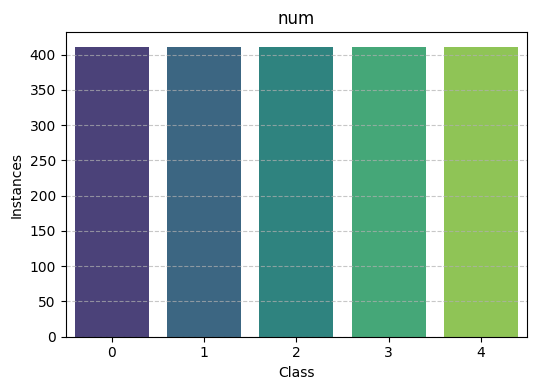


Distribution summary for 'num':
|   Class |   Instances |   Percentage |
|--------:|------------:|-------------:|
|       0 |          28 |        20.00 |
|       1 |          28 |        20.00 |
|       2 |          28 |        20.00 |
|       3 |          28 |        20.00 |
|       4 |          28 |        20.00 |


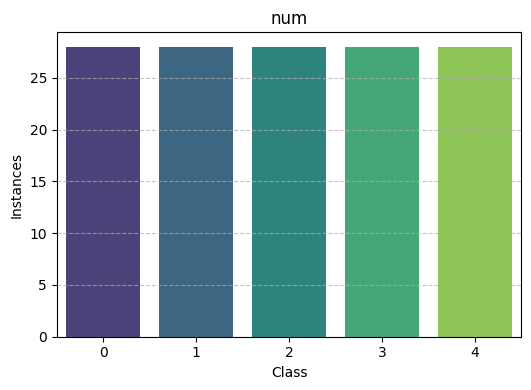


Distribution summary for 'num':
|   Class |   Instances |   Percentage |
|--------:|------------:|-------------:|
|       0 |         201 |        13.82 |
|       1 |         163 |        11.21 |
|       2 |         347 |        23.87 |
|       3 |         340 |        23.38 |
|       4 |         403 |        27.72 |


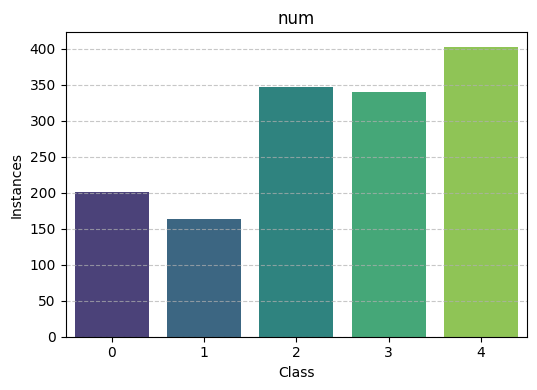

Original shape:  (920, 24)
Oversampled dataset shape (SMOTE): (2055, 24)
Undersampled dataset shape: (140, 24)
Sampled dataset shape (SMOTEENN): (1454, 24)


In [7]:
df_copy = df.copy()
TARGET_COL = 'num'
X_full = df_copy.drop(columns=[TARGET_COL])
y_mc = df_copy[TARGET_COL].astype(int)
y_bin = (y_mc > 0).astype(int)

# Oversampling with SMOTE
smote_sampler = SMOTE(random_state=SEED)
X_smote_mc, y_smote_mc = smote_sampler.fit_resample(X_full, y_mc)
plot_class_distribution(y_smote_mc, columns='num')

# Undersampling with Randome Under Sampler
rand_sampler = RandomUnderSampler(random_state=SEED)
X_under_mc, y_under_mc = rand_sampler.fit_resample(X_full, y_mc)
plot_class_distribution(y_under_mc, columns='num')

# SMOTEENN
smoteenn_sampler = SMOTEENN(random_state=SEED)
X_smoteenn_mc, y_smoteenn_mc = smoteenn_sampler.fit_resample(X_full, y_mc)
plot_class_distribution(y_smoteenn_mc, columns='num')

print('Original shape: ', X_full.shape)
print('Oversampled dataset shape (SMOTE):', X_smote_mc.shape)
print('Undersampled dataset shape:', X_under_mc.shape)
print('Sampled dataset shape (SMOTEENN):', X_smoteenn_mc.shape)

<a id='random-forest'></a>
---
## Random Forest

### Binary

In [ ]:
params_grid = {
    'n_estimators': [700, 800, 900, 1000],
    'max_depth': [6, 7, 8, 9],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', 0.4, 0.6],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced'],
}

In [ ]:
grid = GridSearchCV(
    estimator = RandomForestClassifier(n_jobs=-1, random_state=SEED),
    param_grid = params_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_bin)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_bin, y_pred))*100, 3)

print('Best parameters:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/unbalanced', exist_ok=True)
model_path = '../outputs/models/unbalanced/rf_binary.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best parameters: {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 900}
Accuracy: 83.696
Model saved to:  ../outputs/models/unbalanced/rf_binary.joblib


In [96]:
pipe = Pipeline([
    ('smoteenn', SMOTEENN(random_state=SEED)),
    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

# prefix grid with "model__"
params_grid_pref = {f"model__{k}": v for k, v in params_grid.items()}

grid = GridSearchCV(
    pipe,
    param_grid = params_grid_pref,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'balanced_accuracy',
    n_jobs = -1,
    verbose = 10
)

grid.fit(X_tr, y_tr_bin)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_bin, y_pred))*100, 3)

print('Best parameters:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/smoteenn', exist_ok=True)
model_path = '../outputs/models/smoteenn/rf_binary.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best parameters: {'model__bootstrap': True, 'model__class_weight': None, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__min_samples_split': 4, 'model__n_estimators': 900}
Accuracy: 85.326
Model saved to:  ../outputs/models/smoteenn/rf_binary.joblib


### Multiclass

In [100]:
params_grid = {
    'n_estimators': [600, 700, 800, 900, 1000],
    'max_depth': [7, 8, 9],
    'min_samples_split': [1, 2, 3, 7, 8, 9],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
}

In [101]:
grid = GridSearchCV(
    estimator = RandomForestClassifier(n_jobs=-1, random_state=SEED),
    param_grid = params_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_mc)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_mc, y_pred))*100, 3)

print('Best parameters:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/unbalanced', exist_ok=True)
model_path = '../outputs/models/unbalanced/rf_multiclass.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 1080 candidates, totalling 5400 fits


KeyboardInterrupt: 

In [ ]:
pipe = Pipeline([
    ('smoteenn', SMOTEENN(random_state=SEED)),
    ('model', RandomForestClassifier(n_jobs=-1, random_state=SEED)),
])

# prefix grid with "model__"
params_grid_pref = {f"model__{k}": v for k, v in params_grid.items()}

grid = GridSearchCV(
    estimator = pipe,
    param_grid = params_grid_pref,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_bin)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_mc, y_pred)) * 100, 3)

print('Best parameters:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/smoteenn', exist_ok=True)
model_path = '../outputs/models/smoteenn/rf_multiclass.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits
Best parameters: {'model__bootstrap': False, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 700}
Accuracy: 59.783
Model saved to:  ../outputs/models/smoteenn/rf_multiclass.joblib


<a id='adaboost'></a>
## AdaBoost

### Binary

In [ ]:
params_grid = {
    'n_estimators': [450, 500, 550],
    'learning_rate': [0.01, 0.05, 0.1],
    'estimator__max_depth': [1, 2, 3, 4],
    'estimator__min_samples_leaf': [1, 2, 3, 4],
    'estimator__class_weight': [None, 'balanced'],
}

In [ ]:
grid = GridSearchCV(
    estimator = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=SEED), random_state=SEED),
    param_grid = params_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_bin)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_bin, y_pred))*100, 3)

print('Best params:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/unbalanced', exist_ok=True)
model_path = '../outputs/models/unbalanced/ada_binary.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params: {'estimator__class_weight': None, 'estimator__max_depth': 2, 'estimator__min_samples_leaf': 1, 'learning_rate': 0.1, 'n_estimators': 500}
Accuracy: 82.609
Model saved to:  ../outputs/models/unbalanced/ada_binary.joblib


In [ ]:
ada_bin_pipe = Pipeline(steps=[
    ('smoteenn', SMOTEENN(random_state=SEED)),
    ('model', AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=SEED), random_state=SEED))
])

# prefix grid with "model__"
params_grid_pref = {f"model__{k}": v for k, v in params_grid.items()}

grid = GridSearchCV(
    ada_bin_pipe,
    param_grid = params_grid_pref,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_bin)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_bin, y_pred))*100, 3)

print('Best params:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/smoteenn', exist_ok=True)
model_path = '../outputs/models/smoteenn/ada_binary.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params: {'model__estimator__class_weight': 'balanced', 'model__estimator__max_depth': 3, 'model__estimator__min_samples_leaf': 2, 'model__learning_rate': 0.05, 'model__n_estimators': 500}
Accuracy: 85.326
Model saved to:  ../outputs/models/smoteenn/ada_binary.joblib


### Multiclass

In [ ]:
params_grid = {
    'n_estimators': [100, 200, 400, 500, 600],
    'learning_rate': [0.01, 0.05, 0.1, 0.5],
    'estimator__max_depth': [1, 2, 3, 4],
    'estimator__min_samples_leaf': [4, 5, 6],
    'estimator__class_weight': [None, 'balanced'],
}

In [ ]:
grid = GridSearchCV(
    estimator = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=SEED), random_state=SEED),
    param_grid = params_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'balanced_accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_mc)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_mc, y_pred))*100, 3)

print('Best params:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/unbalanced', exist_ok=True)
model_path = '../outputs/models/unbalanced/ada_multiclass.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 600 candidates, totalling 3000 fits
Best params: {'estimator__class_weight': 'balanced', 'estimator__max_depth': 2, 'estimator__min_samples_leaf': 5, 'learning_rate': 0.5, 'n_estimators': 100}
Accuracy: 49.457
Model saved to:  ../outputs/models/unbalanced/ada_multiclass.joblib


In [ ]:
pipe = Pipeline(steps=[
    ('smoteenn', SMOTEENN(random_state=SEED)),
    ('model', AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=SEED), random_state=SEED))
])

# prefix grid with "model__"
params_grid_pref = {f"model__{k}": v for k, v in params_grid.items()}

grid = GridSearchCV(
    pipe,
    param_grid = params_grid_pref,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_mc)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_mc, y_pred))*100, 3)

print('Best params:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/smoteenn', exist_ok=True)
model_path = '../outputs/models/smoteenn/ada_multiclass.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 600 candidates, totalling 3000 fits
Best params: {'model__estimator__class_weight': 'balanced', 'model__estimator__max_depth': 3, 'model__estimator__min_samples_leaf': 5, 'model__learning_rate': 0.01, 'model__n_estimators': 500}
Accuracy: 50.543
Model saved to:  ../outputs/models/smoteenn/ada_multiclass.joblib


<a id='xgboost'></a>
## XGBoost


### Binary XGBoost

In [ ]:
params_grid = {
    'n_estimators': [50, 100, 150],   
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 7, 8, 9],
    'min_child_weight': [1, 2, 3, 4, 5],
    'subsample': [0.5, 1.0],
    'reg_lambda': [0.05, 0.5, 0.1, 4.0, 5.0],
}


In [ ]:
xgb = XGBClassifier(
    tree_method = 'hist',
    objective = 'binary:logistic',
    eval_metric = 'logloss',
    n_jobs = -1,
    random_state = SEED,
)

grid = GridSearchCV(
    estimator = xgb,
    param_grid = params_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_bin)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_bin, y_pred))*100, 3)

print('Best params:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/unbalanced', exist_ok=True)
model_path = '../outputs/models/unbalanced/xgb_binary.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best params: {'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 4, 'n_estimators': 50, 'reg_lambda': 4.0, 'subsample': 1.0}
Accuracy: 84.239
Model saved to:  ../outputs/models/unbalanced/xgb_binary.joblib


In [ ]:
pipe = Pipeline(steps=[
    ('smoteenn', SMOTEENN(random_state=SEED)),
    ('model', XGBClassifier(
        tree_method='hist',
        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=SEED,
    )),
])

# prefix grid with "model__"
params_grid_pref = {f"model__{k}": v for k, v in params_grid.items()}

grid = GridSearchCV(
    pipe,
    param_grid = params_grid_pref,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
)

grid.fit(X_tr, y_tr_bin)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_bin, y_pred))*100, 3)

print('Best params:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/smoteenn', exist_ok=True)
model_path = '../outputs/models/smoteenn/xgb_binary.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_child_weight': 2, 'model__n_estimators': 100, 'model__reg_lambda': 0.1, 'model__subsample': 1.0}
Accuracy: 83.696
Model saved to:  ../outputs/models/smoteenn/xgb_binary.joblib


### Multiclass

In [ ]:
params_grid = {
    'n_estimators': [300, 400, 500, 600, 1400, 1600],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [1, 2, 4, 10, 12, 14],
    'min_child_weight': [1, 2, 3, 4],
    'subsample': [0.25, 0.5, 1.0],
    'reg_lambda': [0.2, 0.3, 0.4, 0.5, 0.6],
}

In [98]:
xgb = XGBClassifier(
        tree_method = 'hist',
        objective = 'multi:softprob',
        eval_metric = 'mlogloss',
        n_jobs = -1,
        random_state = SEED,
    )

grid = GridSearchCV(
        estimator = xgb,
        param_grid = params_grid,
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring = 'accuracy',
        n_jobs = -1,
        verbose = 10,
        error_score = 'raise'
    )

grid.fit(X_tr, y_tr_mc)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_mc, y_pred))*100, 3)

print('Best params:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/unbalanced', exist_ok=True)
model_path = '../outputs/models/unbalanced/xgb_multiclass.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 2880 candidates, totalling 14400 fits
Best params: {'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 500, 'reg_lambda': 0.4, 'subsample': 0.25}
Accuracy: 62.5
Model saved to:  ../outputs/models/unbalanced/xgb_multiclass.joblib


In [99]:
pipe = Pipeline(steps=[
    ('smoteenn', SMOTEENN(random_state=SEED)),
    ('model', XGBClassifier(
        tree_method = 'hist',
        objective = 'binary:logistic',
        eval_metric = 'logloss',
        n_jobs = -1,
        random_state = SEED,
    )),
])

# prefix grid with "model__"
params_grid_pref = {f"model__{k}": v for k, v in params_grid.items()}

grid = GridSearchCV(
    pipe,
    param_grid = params_grid_pref,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 10,
    error_score = 'raise'
)

grid.fit(X_tr, y_tr_mc)
best = grid.best_estimator_

y_pred = best.predict(X_te)
score = round((accuracy_score(y_te_mc, y_pred))*100, 3)

print('Best params:', grid.best_params_)
print('Accuracy:', score)

# save the best model
os.makedirs('../outputs/models/smoteenn', exist_ok=True)
model_path = '../outputs/models/unbalanced/xgb_multiclass.joblib'
joblib.dump(best, model_path)
print('Model saved to: ', model_path)

Fitting 5 folds for each of 2880 candidates, totalling 14400 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__min_child_weight': 1, 'model__n_estimators': 1400, 'model__reg_lambda': 0.6, 'model__subsample': 0.5}
Accuracy: 54.348
Model saved to:  ../outputs/models/unbalanced/xgb_multiclass.joblib
